# Kaggle
# Context
## A response model can provide a significant boost to the efficiency of a marketing campaign by increasing responses or reducing expenses. The objective is to predict who will respond to an offer for a product or service

# Inspiration
## The main objective is to train a predictive model which allows the company to maximize the profit of the next marketing campaign.

### Pipeline : Cleaning Raw Data -> Encoding -> Train/Test split -> Model training -> Predictor (probability assignment) -> Taking desicion

In [54]:
# import libraries
import sys 
import numpy as np
import pandas as pd 
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)


import tarfile
import urllib

# Get the data

In [55]:
marketing_campaign_data_path = os.path.join("datasets", "marketing_campaign")
def get_data(path_data = marketing_campaign_data_path):
    csv_file = os.path.join(path_data, "marketing_campaign.csv")
    return pd.read_csv(csv_file, sep=";")

df_marketing = get_data()
df_marketing.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


# Data Understanding 

In [56]:
# Overall information data type 
df_marketing.info()

num_cols = df_marketing.select_dtypes(include=['number'])
cat_cols = df_marketing.select_dtypes(include=['object', 'category'])

print("Numerical columns in the data set:", num_cols.shape[1])
print("Categorical columns in the data set:", cat_cols.shape[1])
print("Number of columns in the data set", (num_cols + cat_cols).shape[1])

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [57]:
# numerical properties summary 
df_marketing.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [58]:
# target variable 
print("Counts of response variable", df_marketing["Response"].value_counts())


Counts of response variable Response
0    1906
1     334
Name: count, dtype: int64


----------------Campaign behavior-----------------
The most accepted campaign is:  Cmp4


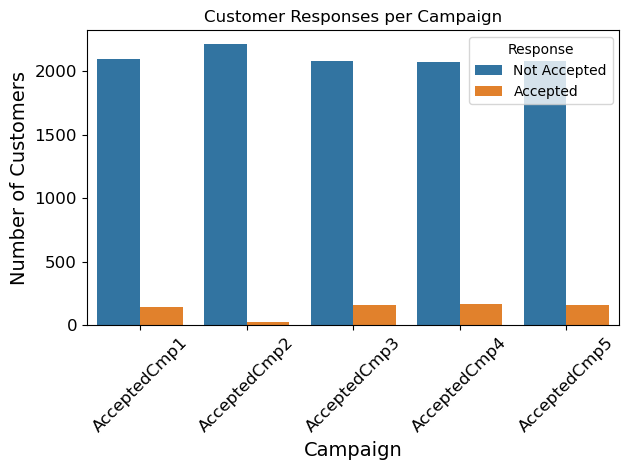

----------Customer personal information-----------
The mean income value is: 52247.25 US


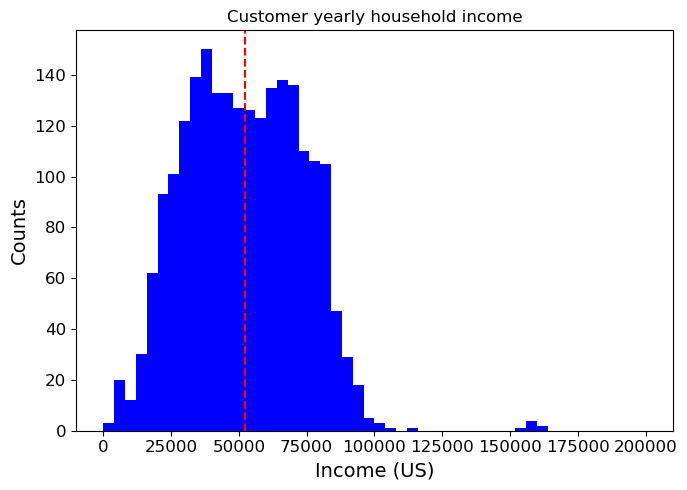

The most common marital status is: Married
The most frequent number of small children is: 0
The most frequent number of teenagers is: 0


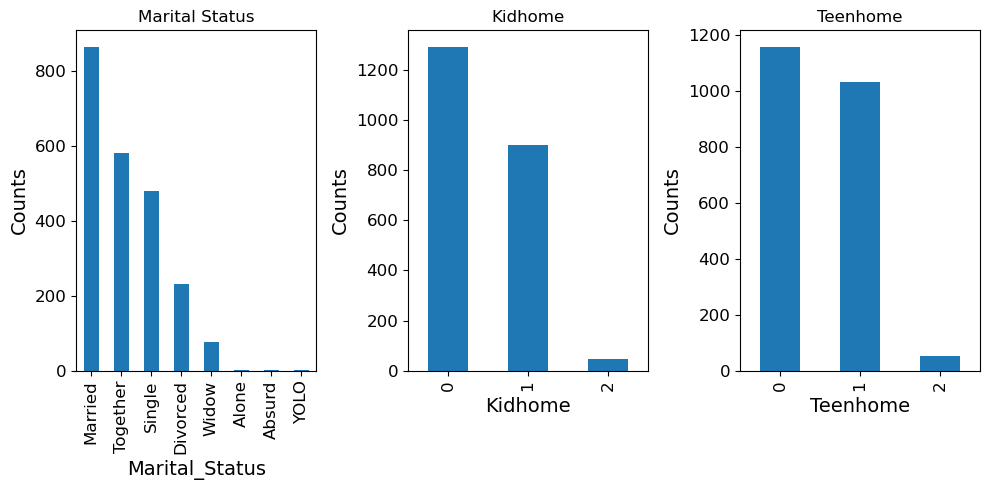

---How much the customer spends in the products---
Product that customer spends more is: Wines


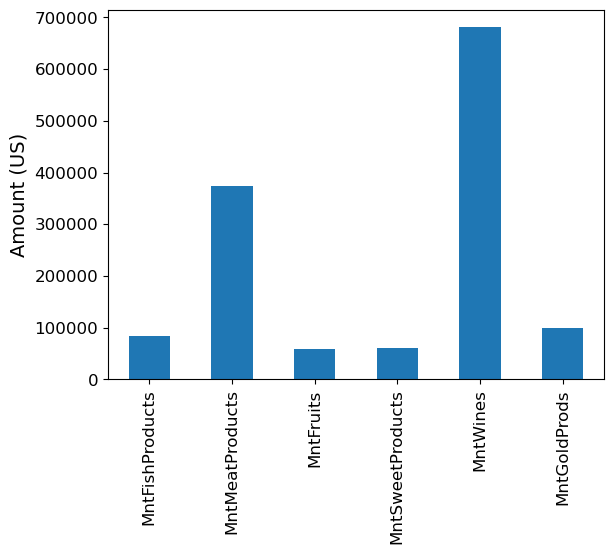

--------Customer interactions with company--------
the most common type of purchase is StorePurchases


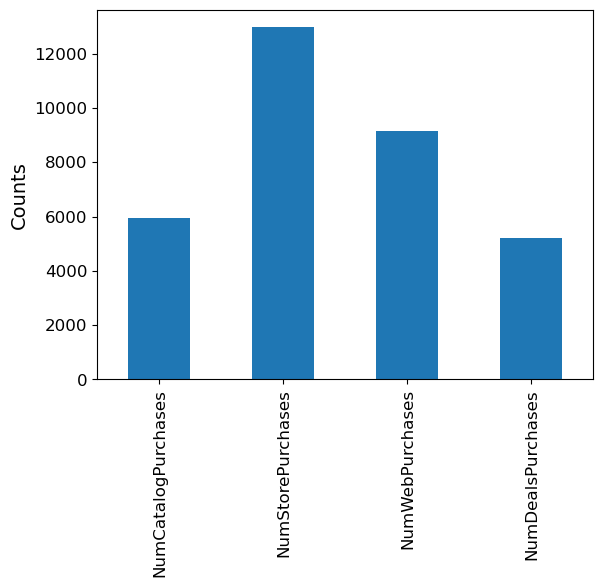

-----------Days since the last purchase-----------
The last time that most customers buy is:  56


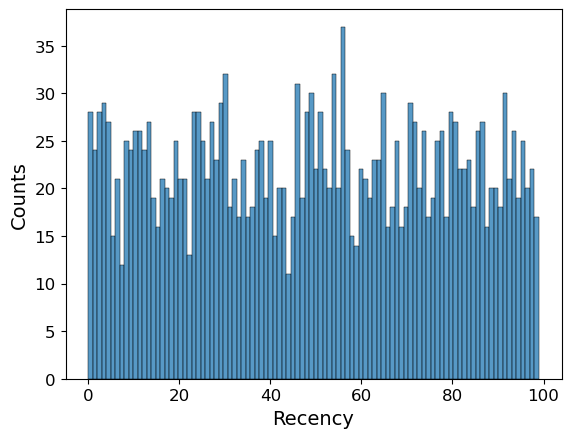

In [59]:
import seaborn as sns
import math

# Campaign behavior 

print("Campaign behavior".center(50,"-"))

camp_response_list = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
## retrieve the most accepted campaign
campaign_counts = df_marketing[camp_response_list].sum()
most_accepted_campaign = campaign_counts.idxmax()
print("The most accepted campaign is: ", most_accepted_campaign[8:])

## Create a data set:  campaign type | Accepted value
df_reshape = df_marketing[camp_response_list].melt(var_name="Campaign", value_name="Accepted")
sns.countplot(data=df_reshape, x="Campaign", hue="Accepted")
plt.legend(title="Response", labels=["Not Accepted", "Accepted"])
plt.ylabel("Number of Customers")
plt.title("Customer Responses per Campaign")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()

# Personal Customer Information

print("Customer personal information".center(50,"-"))

mean_in = df_marketing["Income"].mean()
print(f"The mean income value is: {mean_in:.2f} US")

fig, axs = plt.subplots(figsize=(7,5))
axs.hist(df_marketing["Income"], bins = 50, color = 'b', range = (0,200000))
axs.axvline(x=mean_in, color = 'r', linestyle = '--')
plt.xlabel("Income (US)")
plt.ylabel("Counts")
plt.title("Customer yearly household income")
plt.tight_layout()
plt.show()
plt.close()

## Customer Marital status distribution

fig,axs = plt.subplots(1,3, figsize = (10,5))

print("The most common marital status is:", df_marketing["Marital_Status"].value_counts().idxmax())
print("The most frequent number of small children is:", df_marketing["Kidhome"].value_counts().idxmax())
print("The most frequent number of teenagers is:", df_marketing["Teenhome"].value_counts().idxmax())

axs = axs.flatten()
df_marketing["Marital_Status"].value_counts().plot(kind="bar", ax = axs[0])
df_marketing["Kidhome"].value_counts().plot(kind="bar", ax = axs[1])
df_marketing["Teenhome"].value_counts().plot(kind="bar", ax = axs[2])
axs[0].set_title("Marital Status")
axs[1].set_title("Kidhome")
axs[2].set_title("Teenhome")

for ax in axs:
    ax.set_ylabel("Counts")

plt.tight_layout()
plt.show()
plt.close()


# Behavior analysis
print("How much the customer spends in the products".center(50,"-"))
fig, ax = plt.subplots()
amount_prod_list = ['MntFishProducts', 'MntMeatProducts', 'MntFruits', 'MntSweetProducts', 'MntWines', 'MntGoldProds'] 
print("Product that customer spends more is:", df_marketing[amount_prod_list].sum().idxmax()[3:])

df_marketing[amount_prod_list].sum().plot(kind="bar")
plt.ylabel("Amount (US)")
plt.show()
plt.close()

df_marketing[amount_prod_list].describe()

# Purchase channel analysis
print("Customer interactions with company".center(50,"-"))

fig, ax = plt.subplots()
purchase_list = ['NumCatalogPurchases', 'NumStorePurchases', 'NumWebPurchases', 'NumDealsPurchases']
print("the most common type of purchase is", df_marketing[purchase_list].sum().idxmax()[3:])
df_marketing[purchase_list].sum().plot(kind = "bar")
plt.ylabel("Counts")
plt.show()
plt.close()

# Recency analysis
print("Days since the last purchase".center(50,"-"))
fig, ax = plt.subplots()
print("The last time that most customers buy is: ", df_marketing["Recency"].value_counts().idxmax())
sns.histplot(data = df_marketing, x="Recency", bins = 100)
plt.ylabel("Counts")
plt.show()
plt.close()




# Feature Engine

In [60]:
# lets print the correlations with our target variable
corr_matrix = df_marketing.select_dtypes(include="number").corr()

corr_matrix["Response"].sort_values(ascending = False)

Response               1.000000
AcceptedCmp5           0.326634
AcceptedCmp1           0.293982
AcceptedCmp3           0.254258
MntWines               0.247254
MntMeatProducts        0.236335
NumCatalogPurchases    0.220810
AcceptedCmp4           0.177019
AcceptedCmp2           0.169293
NumWebPurchases        0.148730
MntGoldProds           0.139850
Income                 0.133047
MntFruits              0.125289
MntSweetProducts       0.117372
MntFishProducts        0.111331
NumStorePurchases      0.039363
Year_Birth             0.021325
NumDealsPurchases      0.002238
Complain              -0.001707
NumWebVisitsMonth     -0.003987
ID                    -0.021968
Kidhome               -0.080008
Teenhome              -0.154446
Recency               -0.198437
Z_CostContact               NaN
Z_Revenue                   NaN
Name: Response, dtype: float64

In [61]:
# lest define the total spending on products in the last 2 years
df_marketing["TotalMntProd"] = df_marketing["MntWines"] + df_marketing["MntFruits"] +  df_marketing["MntMeatProducts"] + df_marketing["MntFishProducts"] + \
            df_marketing["MntSweetProducts"] + df_marketing["MntGoldProds"]
# lets define the total purchase
df_marketing["TotalPurchase"] = df_marketing["NumWebPurchases"] + df_marketing["NumCatalogPurchases"] + df_marketing["NumStorePurchases"]
# again lets calculate the correlation matrix to verify whether or not improve the correlations
corr_matrix = df_marketing.select_dtypes(include="number").corr()
corr_matrix["Response"].sort_values(ascending = False)

Response               1.000000
AcceptedCmp5           0.326634
AcceptedCmp1           0.293982
TotalMntProd           0.265298
AcceptedCmp3           0.254258
MntWines               0.247254
MntMeatProducts        0.236335
NumCatalogPurchases    0.220810
AcceptedCmp4           0.177019
AcceptedCmp2           0.169293
TotalPurchase          0.164688
NumWebPurchases        0.148730
MntGoldProds           0.139850
Income                 0.133047
MntFruits              0.125289
MntSweetProducts       0.117372
MntFishProducts        0.111331
NumStorePurchases      0.039363
Year_Birth             0.021325
NumDealsPurchases      0.002238
Complain              -0.001707
NumWebVisitsMonth     -0.003987
ID                    -0.021968
Kidhome               -0.080008
Teenhome              -0.154446
Recency               -0.198437
Z_CostContact               NaN
Z_Revenue                   NaN
Name: Response, dtype: float64

In [62]:
# lets drop the NaN correlation values (useless for ML)
df_marketing = df_marketing.drop(columns=["Z_CostContact", "Z_Revenue"])

## Data cleaning


In [63]:
# Missing data 
print("missing data")
df_marketing.isnull().sum()

missing data


ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
TotalMntProd            0
TotalPurchase           0
dtype: int64

In [64]:
# lets handle the missing value
median = df_marketing["Income"].median()
df_marketing["Income"] = df_marketing["Income"].fillna(median)
df_marketing["Income"].isnull().sum()

0

In [65]:
# Duplicated values
print("duplicated values")
df_marketing.duplicated().sum()

duplicated values


0

## Handling Text and Categorical Attributes

In [66]:
from sklearn.preprocessing import OneHotEncoder
cat_col_name = ["Education"]

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

encoded = encoder.fit_transform(df_marketing[cat_col_name])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(cat_col_name),
    index=df_marketing.index
)

df_marketing = pd.concat(
    [df_marketing.drop(columns=cat_col_name), encoded_df],
    axis=1
)
# lets drop useless categorical variables
df_marketing = df_marketing.drop(columns=["Marital_Status", "Dt_Customer"])


In [67]:
# lets make a copy for the data set that will be used for trainning
df_marketing_prep = df_marketing.copy()

df_marketing_prep.head()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp2,Complain,Response,TotalMntProd,TotalPurchase,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD
0,5524,1957,58138.0,0,0,58,635,88,546,172,...,0,0,1,1617,22,0.0,0.0,1.0,0.0,0.0
1,2174,1954,46344.0,1,1,38,11,1,6,2,...,0,0,0,27,4,0.0,0.0,1.0,0.0,0.0
2,4141,1965,71613.0,0,0,26,426,49,127,111,...,0,0,0,776,20,0.0,0.0,1.0,0.0,0.0
3,6182,1984,26646.0,1,0,26,11,4,20,10,...,0,0,0,53,6,0.0,0.0,1.0,0.0,0.0
4,5324,1981,58293.0,1,0,94,173,43,118,46,...,0,0,0,422,14,0.0,0.0,0.0,0.0,1.0


# Train the Model

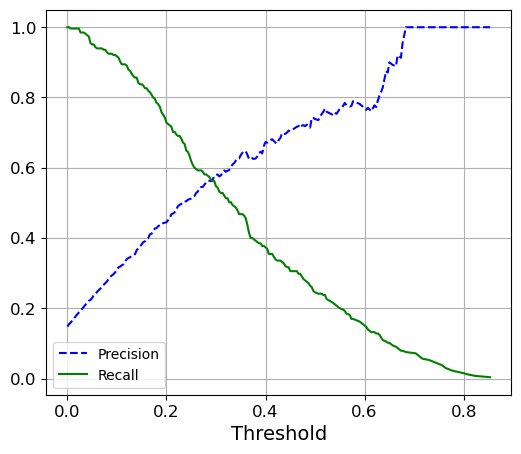

Best threshold: 0.22666666666666666
Accuracy: 0.8415178571428571
[[335  44]
 [ 27  42]]
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       379
           1       0.49      0.61      0.54        69

    accuracy                           0.84       448
   macro avg       0.71      0.75      0.72       448
weighted avg       0.86      0.84      0.85       448



In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import precision_recall_curve

Y = df_marketing_prep['Response']
X = df_marketing_prep.drop(['Response'], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=300,class_weight="balanced",random_state=42)
model.fit(X_train, y_train)

# cross validation on the first class
y_scores = cross_val_predict(model, X_train, y_train, cv=3, method="predict_proba")[:,1]

precision, recall, thresholds = precision_recall_curve(y_train, y_scores)

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.figure(figsize=(6,5))
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.xlabel("Threshold")
    plt.grid()
    plt.legend()

plot_precision_recall_vs_threshold(precision, recall, thresholds)
plt.show()

#get the optimal threshold 
f1 = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])

best_threshold_id = np.argmax(f1)
best_threshold = thresholds[best_threshold_id]

print("Best threshold:", best_threshold )

y_prob = model.predict_proba(X_test)[:,1]
y_pred = (y_prob > best_threshold).astype(int)

# test evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


### How understand our metrics ? 
#### Precision: low precision means that probably some bad customers slip through (correctly targeted customers/all targeted customers)
##### We found an optimal precision of 49 %, that means from all customers we targeted as buyers 49% of them will accept our offer.
#### Recall: low recall means we miss good buyers (correctly targeted customers/all customers we would accept the offer).
#####  We found an optimal recall of 61 %, that means that we found 61% of buyers


# ROI estimation (Profit/Total Cost)

In [69]:
TP = 42
FP = 44

gain = 20 #in USD which is the gain when the customer accept the offer 
cost = 1  #in USD which is how much contact to a new customer 

profit = TP*gain - (TP+FP)*cost
roi = profit / ((TP+FP)*cost) * 100

print("ROI: %.1f%%" % roi)
print(f"For every 1 USD spent, you earn: {roi/100} USD")

ROI: 876.7%
For every 1 USD spent, you earn: 8.767441860465116 USD


# Evaluate our model on "new customers"

In [77]:
df_test = X_test.copy()
df_test["prob_response"] = y_prob
df_test = df_test.sort_values("prob_response", ascending=False)
print(df_test[["ID", "prob_response"]].to_string(index=False))


   ID  prob_response
 5547       0.783333
 7101       0.690000
 5093       0.686667
 5049       0.663333
 7832       0.656667
 1509       0.650000
 6798       0.646667
10905       0.640000
 9826       0.633333
 7261       0.613333
 5172       0.606667
 2798       0.603333
 6072       0.580000
 3711       0.563333
 3725       0.563333
 8685       0.553333
 7215       0.540000
 7962       0.516667
 8015       0.516667
 1340       0.513333
 8346       0.513333
 5236       0.510000
  837       0.510000
 9264       0.496667
 8254       0.496667
 7141       0.476667
 2131       0.470000
 3138       0.426667
 7912       0.426667
 1361       0.423333
 1031       0.416667
 2909       0.410000
  938       0.403333
 5341       0.400000
 6299       0.396667
 9369       0.393333
 4656       0.390000
 7494       0.383333
 1857       0.383333
 1859       0.383333
 6504       0.380000
 5113       0.380000
 1175       0.373333
 2942       0.373333
10469       0.373333
 7431       0.360000
  175       0